# Deep Learning Image Classification — 10+ Classes
## Using ResNet50, EfficientNet, DenseNet, VGG, InceptionV3, MobileNetV2

**Dataset:** CIFAR-100 (100 classes, 60,000 images) — easily swappable with ImageNet, Food-101, etc.

## JATIN THAKUR 255030001

---

In [1]:
# Install required packages (run once)
!pip install torch torchvision timm matplotlib seaborn scikit-learn tqdm pandas numpy albumentations --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import CIFAR100

import timm  # PyTorch Image Models — includes EfficientNet, ConvNeXt, etc.

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    top_k_accuracy_score
)

# ── Device Setup ──────────────────────────────────────────────────────────────
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)
print(f"✅ Using device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✅ Using device: cuda
   GPU: NVIDIA GeForce RTX 3070 Ti
   VRAM: 8.6 GB


In [3]:
# ════════════════════════════════════════════════════════════
#  CONFIGURATION  — Edit freely
# ════════════════════════════════════════════════════════════

CFG = {
    # ── Dataset ───────────────────────────────────────────
    "dataset":       "CIFAR100",   # CIFAR100 | CIFAR10 | custom
    "num_classes":   100,          # CIFAR100=100, CIFAR10=10
    "data_dir":      "./data",
    "img_size":      224,          # Resize to this (224 works for all models)
    
    # ── Model — pick ONE ─────────────────────────────────
    # torchvision: resnet50, resnet101, resnet152, vgg16, vgg19,
    #              densenet121, densenet169, densenet201,
    #              inception_v3, mobilenet_v2
    # timm:        efficientnet_b0..b7, convnext_small, convnext_base,
    #              resnext50_32x4d, wide_resnet50_2
    "model_name":    "resnet50",   # ← Change this
    "use_timm":      False,        # True if model_name is from timm
    "pretrained":    True,         # Use ImageNet pretrained weights
    "freeze_backbone": False,      # Freeze all layers except the classifier head

    # ── Training ──────────────────────────────────────────
    "epochs":        20,
    "batch_size":    64,
    "lr":            1e-4,
    "weight_decay":  1e-4,
    "scheduler":     "cosine",     # cosine | step | none
    "label_smoothing": 0.1,
    "early_stop_patience": 5,

    # ── Augmentation ──────────────────────────────────────
    "use_mixup":     False,
    "mixup_alpha":   0.4,

    # ── Misc ──────────────────────────────────────────────
    "seed":          42,
    "num_workers":   4,
    "val_split":     0.1,
    "save_best":     True,
    "checkpoint_path": "best_model.pth",
}

# Reproducibility
torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])
print("Configuration loaded ✅")
print(f"  Model    : {CFG['model_name']}")
print(f"  Dataset  : {CFG['dataset']} ({CFG['num_classes']} classes)")
print(f"  Epochs   : {CFG['epochs']}  |  Batch: {CFG['batch_size']}  |  LR: {CFG['lr']}")

Configuration loaded ✅
  Model    : resnet50
  Dataset  : CIFAR100 (100 classes)
  Epochs   : 20  |  Batch: 64  |  LR: 0.0001


In [4]:
# ── ImageNet normalization (used even for non-ImageNet datasets when pretrained=True)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((CFG["img_size"] + 32, CFG["img_size"] + 32)),
    transforms.RandomCrop(CFG["img_size"]),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((CFG["img_size"], CFG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ── Load Dataset ─────────────────────────────────────────────────────────────
print("Downloading / Loading dataset...")

full_train = CIFAR100(root=CFG["data_dir"], train=True,  download=True, transform=train_transform)
test_set   = CIFAR100(root=CFG["data_dir"], train=False, download=True, transform=val_transform)

# Val split from training data
val_size   = int(len(full_train) * CFG["val_split"])
train_size = len(full_train) - val_size
train_set, val_set = random_split(full_train, [train_size, val_size],
                                  generator=torch.Generator().manual_seed(CFG["seed"]))

# Apply val transform to val_set by wrapping it
class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        x, y = self.subset[idx]
        # x is already a tensor from train_transform; just return as-is
        return x, y

train_loader = DataLoader(train_set, batch_size=CFG["batch_size"], shuffle=True,
                          num_workers=CFG["num_workers"], pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=CFG["num_workers"], pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=CFG["num_workers"], pin_memory=True)

CLASS_NAMES = full_train.classes

print(f"\nDataset split:")
print(f"  Train : {train_size:,}")
print(f"  Val   : {val_size:,}")
print(f"  Test  : {len(test_set):,}")
print(f"  Classes: {CFG['num_classes']}")

100%|██████████| 169M/169M [00:18<00:00, 9.01MB/s] 



Dataset split:
  Train : 45,000
  Val   : 5,000
  Test  : 10,000
  Classes: 100


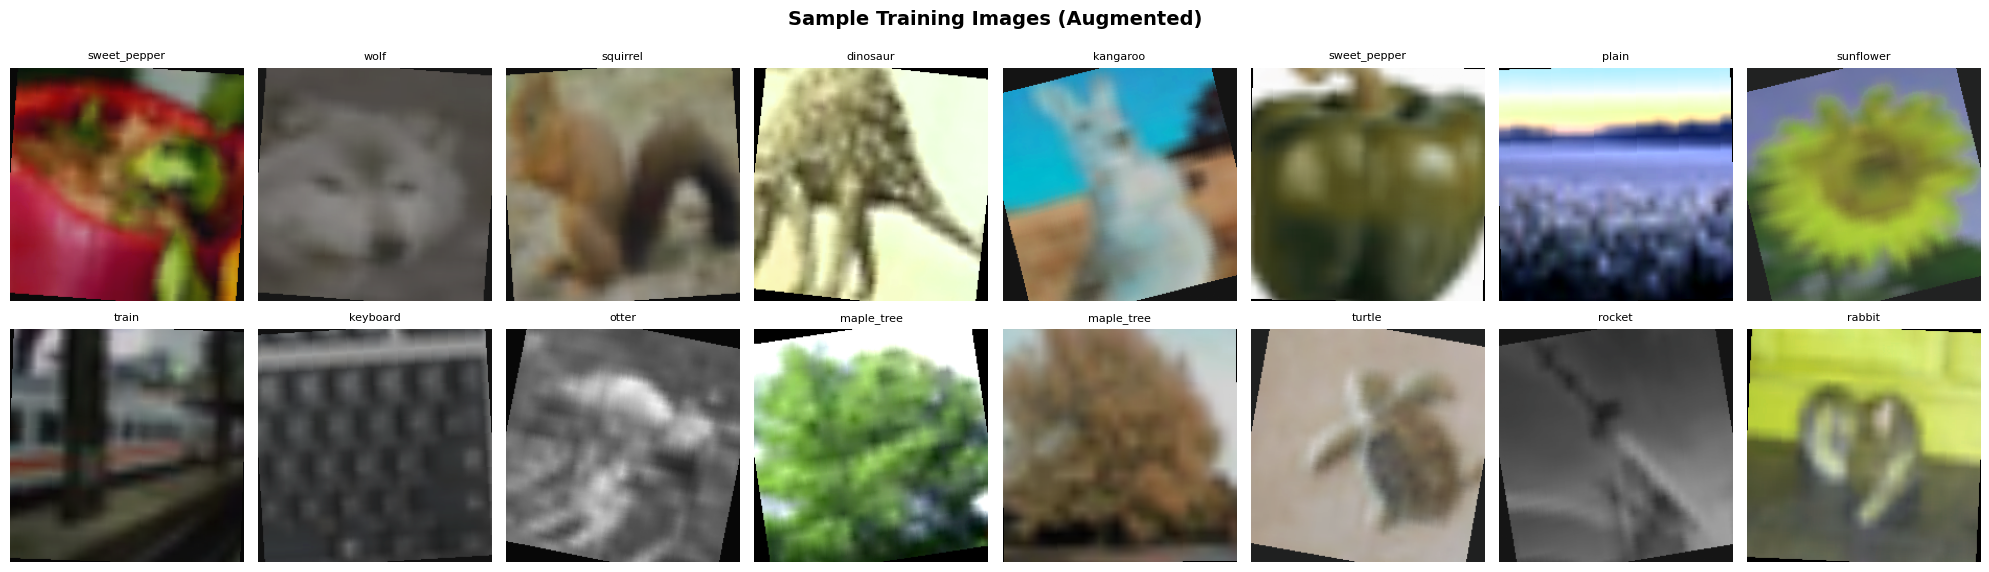

In [5]:
# ── Visualize Sample Images ───────────────────────────────────────────────────
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    return torch.clamp(tensor * std + mean, 0, 1)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle("Sample Training Images (Augmented)", fontsize=14, fontweight="bold")
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[labels[i].item()], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [6]:
def build_model(cfg: dict) -> nn.Module:
    """
    Build a classification model from torchvision or timm.
    Automatically replaces the final classification head.
    """
    name       = cfg["model_name"]
    n_classes  = cfg["num_classes"]
    pretrained = cfg["pretrained"]
    use_timm   = cfg["use_timm"]

    if use_timm:
        model = timm.create_model(name, pretrained=pretrained, num_classes=n_classes)
        print(f"[timm] {name} loaded (pretrained={pretrained})")
        return model

    # ── torchvision models ───────────────────────────────────────────────────
    weights_flag = "DEFAULT" if pretrained else None

    # ResNet family
    if name == "resnet50":    model = models.resnet50(weights=weights_flag)
    elif name == "resnet101": model = models.resnet101(weights=weights_flag)
    elif name == "resnet152": model = models.resnet152(weights=weights_flag)

    # VGG
    elif name == "vgg16":     model = models.vgg16(weights=weights_flag)
    elif name == "vgg19":     model = models.vgg19(weights=weights_flag)

    # DenseNet
    elif name == "densenet121": model = models.densenet121(weights=weights_flag)
    elif name == "densenet169": model = models.densenet169(weights=weights_flag)
    elif name == "densenet201": model = models.densenet201(weights=weights_flag)

    # Inception
    elif name == "inception_v3":
        model = models.inception_v3(weights=weights_flag, aux_logits=False)

    # MobileNet
    elif name == "mobilenet_v2":   model = models.mobilenet_v2(weights=weights_flag)
    elif name == "mobilenet_v3_large": model = models.mobilenet_v3_large(weights=weights_flag)

    # EfficientNet (torchvision)
    elif name == "efficientnet_b0": model = models.efficientnet_b0(weights=weights_flag)
    elif name == "efficientnet_b4": model = models.efficientnet_b4(weights=weights_flag)
    elif name == "efficientnet_b7": model = models.efficientnet_b7(weights=weights_flag)

    # ConvNeXt (torchvision)
    elif name == "convnext_small":  model = models.convnext_small(weights=weights_flag)
    elif name == "convnext_base":   model = models.convnext_base(weights=weights_flag)

    else:
        raise ValueError(f"Unknown model: {name}. Set use_timm=True for timm models.")

    # ── Replace classification head ──────────────────────────────────────────
    if hasattr(model, "fc"):          # ResNet, Inception
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, n_classes)
        )
    elif hasattr(model, "classifier"):  # VGG, DenseNet, MobileNet, EfficientNet
        if isinstance(model.classifier, nn.Linear):   # DenseNet
            in_features = model.classifier.in_features
            model.classifier = nn.Sequential(
                nn.Dropout(0.3),
                nn.Linear(in_features, n_classes)
            )
        elif isinstance(model.classifier, nn.Sequential):
            # Find last Linear layer
            for i, layer in reversed(list(enumerate(model.classifier))):
                if isinstance(layer, nn.Linear):
                    in_features = layer.in_features
                    model.classifier[i] = nn.Linear(in_features, n_classes)
                    break
    elif hasattr(model, "head"):       # ConvNeXt
        if hasattr(model.head, "fc"):
            in_features = model.head.fc.in_features
            model.head.fc = nn.Linear(in_features, n_classes)
        else:
            in_features = model.head.in_features
            model.head = nn.Linear(in_features, n_classes)

    # ── Optional: Freeze backbone ────────────────────────────────────────────
    if cfg.get("freeze_backbone", False):
        for name_, param in model.named_parameters():
            if "fc" not in name_ and "classifier" not in name_ and "head" not in name_:
                param.requires_grad = False
        print("Backbone frozen — only head will train.")

    # Model info
    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[torchvision] {name} loaded (pretrained={pretrained})")
    print(f"  Total params    : {total_params/1e6:.2f} M")
    print(f"  Trainable params: {trainable_params/1e6:.2f} M")

    return model

model = build_model(CFG).to(device)
print(f"\nModel ready on {device} ✅")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\NZXT/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:07<00:00, 13.6MB/s]


[torchvision] resnet50 loaded (pretrained=True)
  Total params    : 23.71 M
  Trainable params: 23.71 M

Model ready on cuda ✅


In [7]:
# ── Loss with Label Smoothing ─────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=CFG["label_smoothing"])

# ── Optimizer ────────────────────────────────────────────────────────────────
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"]
)

# ── LR Scheduler ─────────────────────────────────────────────────────────────
if CFG["scheduler"] == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG["epochs"])
elif CFG["scheduler"] == "step":
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
else:
    scheduler = None

# ── MixUp utility ────────────────────────────────────────────────────────────
def mixup_data(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1
    idx = torch.randperm(x.size(0)).to(device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    return mixed_x, y, y[idx], lam

def mixup_criterion(criterion, pred, ya, yb, lam):
    return lam * criterion(pred, ya) + (1 - lam) * criterion(pred, yb)

print("Optimizer, criterion and scheduler configured ✅")

Optimizer, criterion and scheduler configured ✅


In [8]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, cfg):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(loader, desc="Train", leave=False):
        images, labels = images.to(device), labels.to(device)

        if cfg["use_mixup"]:
            images, labels_a, labels_b, lam = mixup_data(images, labels, cfg["mixup_alpha"])

        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            outputs = model(images)
            if cfg["use_mixup"]:
                loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
            else:
                loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        if not cfg["use_mixup"]:
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
        total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = correct / total if not cfg["use_mixup"] else 0.0
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    for images, labels in tqdm(loader, desc="Eval ", leave=False):
        images, labels = images.to(device), labels.to(device)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            outputs = model(images)
            loss    = criterion(outputs, labels)

        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        running_loss += loss.item() * images.size(0)
        correct += predicted.eq(labels).sum().item()
        total   += images.size(0)
        all_preds.append(predicted.cpu())
        all_labels.append(labels.cpu())
        all_probs.append(probs.cpu())

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_probs  = torch.cat(all_probs).numpy()
    return epoch_loss, epoch_acc, all_preds, all_labels, all_probs

print("Training functions defined ✅")

Training functions defined ✅


In [9]:
# ── Main Training Loop ────────────────────────────────────────────────────────
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
best_val_acc   = 0.0
best_val_loss  = float("inf")
patience_count = 0
scaler         = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

print(f"\n{'='*60}")
print(f"  Training {CFG['model_name']} on {CFG['dataset']} | {CFG['epochs']} epochs")
print(f"{'='*60}\n")

for epoch in range(1, CFG["epochs"] + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, CFG)
    val_loss,   val_acc, _, _, _ = evaluate(model, val_loader, criterion)

    if scheduler:
        scheduler.step()

    current_lr = optimizer.param_groups[0]["lr"]
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    elapsed = time.time() - t0
    print(f"Epoch [{epoch:>3}/{CFG['epochs']}] "
          f"| Train Loss: {train_loss:.4f}  Acc: {train_acc*100:.2f}% "
          f"| Val Loss: {val_loss:.4f}  Acc: {val_acc*100:.2f}% "
          f"| LR: {current_lr:.2e}  | {elapsed:.1f}s")

    # Save best model
    if val_acc > best_val_acc and CFG["save_best"]:
        best_val_acc = val_acc
        torch.save({
            "epoch":       epoch,
            "model_state": model.state_dict(),
            "optimizer":   optimizer.state_dict(),
            "val_acc":     val_acc,
            "cfg":         CFG,
        }, CFG["checkpoint_path"])
        print(f"  ✅ Saved best model (val_acc={best_val_acc*100:.2f}%)")
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= CFG["early_stop_patience"]:
            print(f"\n⏹ Early stopping triggered at epoch {epoch}")
            break

print(f"\nTraining complete! Best Val Acc: {best_val_acc*100:.2f}%")


  Training resnet50 on CIFAR100 | 20 epochs



C:\Users\NZXT\AppData\Local\Temp\ipykernel_28184\1691673965.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler         = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


Train:   0%|          | 0/704 [00:00<?, ?it/s]

C:\Users\NZXT\AppData\Local\Temp\ipykernel_28184\193666183.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Eval :   0%|          | 0/79 [00:00<?, ?it/s]

...

Eval :   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [ 19/20] | Train Loss: 0.8524  Acc: 98.66% | Val Loss: 1.3710  Acc: 81.98% | LR: 6.16e-07  | 119.6s


Train:   0%|          | 0/704 [00:00<?, ?it/s]

Eval :   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [ 20/20] | Train Loss: 0.8534  Acc: 98.52% | Val Loss: 1.3685  Acc: 81.98% | LR: 0.00e+00  | 119.9s

Training complete! Best Val Acc: 82.12%


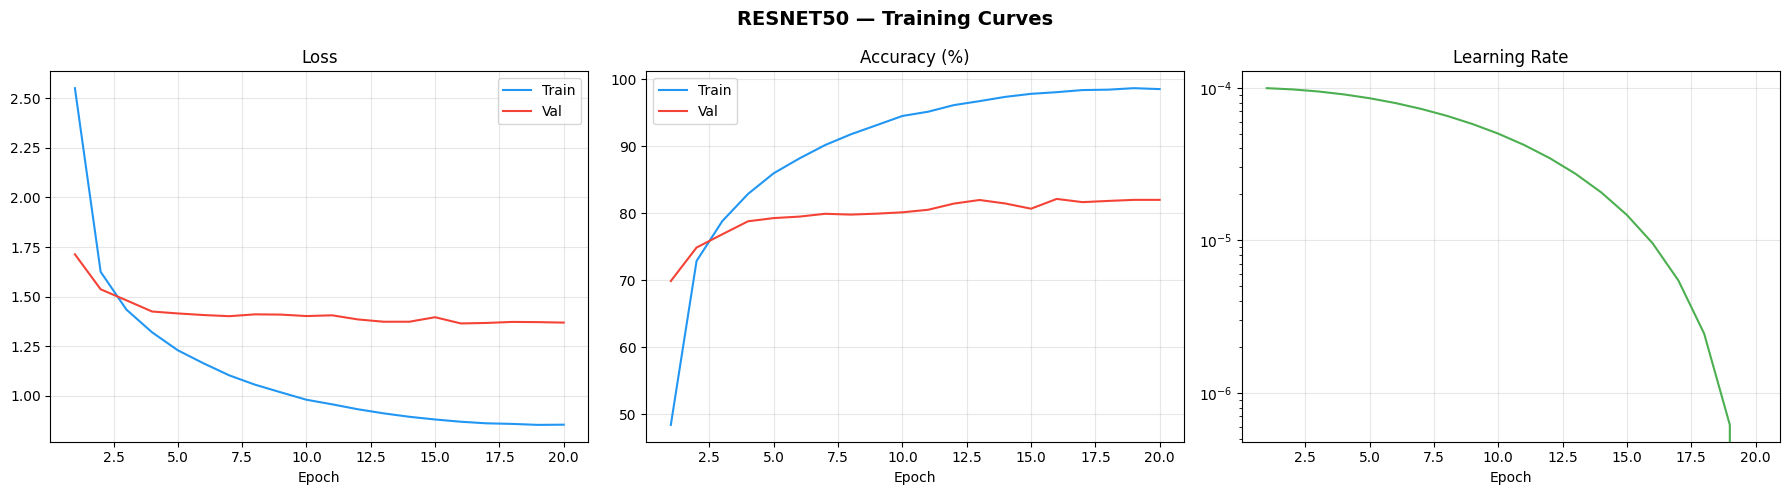

In [10]:
epochs_ran = len(history["train_loss"])
x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"{CFG['model_name'].upper()} — Training Curves", fontsize=14, fontweight="bold")

# Loss
axes[0].plot(x, history["train_loss"], label="Train", color="#2196F3")
axes[0].plot(x, history["val_loss"],   label="Val",   color="#F44336")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(x, [a*100 for a in history["train_acc"]], label="Train", color="#2196F3")
axes[1].plot(x, [a*100 for a in history["val_acc"]],   label="Val",   color="#F44336")
axes[1].set_title("Accuracy (%)"); axes[1].set_xlabel("Epoch"); axes[1].legend()
axes[1].grid(alpha=0.3)

# Learning Rate
axes[2].plot(x, history["lr"], color="#4CAF50")
axes[2].set_title("Learning Rate"); axes[2].set_xlabel("Epoch")
axes[2].set_yscale("log"); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# Load best checkpoint
if CFG["save_best"] and os.path.exists(CFG["checkpoint_path"]):
    ckpt = torch.load(CFG["checkpoint_path"], map_location=device)
    model.load_state_dict(ckpt["model_state"])
    print(f"Loaded best checkpoint from epoch {ckpt['epoch']} (val_acc={ckpt['val_acc']*100:.2f}%)")

test_loss, test_acc, test_preds, test_labels, test_probs = evaluate(model, test_loader, criterion)

# Top-5 accuracy
top5_acc = top_k_accuracy_score(test_labels, test_probs, k=5, labels=list(range(CFG["num_classes"])))

print(f"\n{'='*40}")
print(f"  Test Results — {CFG['model_name']}")
print(f"{'='*40}")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Top-1 Acc: {test_acc*100:.2f}%")
print(f"  Test Top-5 Acc: {top5_acc*100:.2f}%")
print(f"{'='*40}")

Loaded best checkpoint from epoch 16 (val_acc=82.12%)


Eval :   0%|          | 0/157 [00:00<?, ?it/s]

C:\Users\NZXT\AppData\Local\Temp\ipykernel_28184\193666183.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):



  Test Results — resnet50
  Test Loss     : 1.3015
  Test Top-1 Acc: 84.20%
  Test Top-5 Acc: 97.03%


In [13]:
report = classification_report(test_labels, test_preds,
                                target_names=CLASS_NAMES, output_dict=True)
report_df = pd.DataFrame(report).T.drop(columns=["support"])
report_df = report_df.drop(index=["accuracy", "macro avg", "weighted avg"])

# Top 10 best & worst classes
print("\n📗 Top 10 Best Predicted Classes:")
print(report_df.sort_values("f1-score", ascending=False).head(10).to_string())
print("\n📕 Top 10 Worst Predicted Classes:")
print(report_df.sort_values("f1-score", ascending=True).head(10).to_string())


📗 Top 10 Best Predicted Classes:
              precision  recall  f1-score
lawn_mower     0.942308    0.98  0.960784
pickup_truck   0.950980    0.97  0.960396
sunflower      0.969388    0.95  0.959596
tank           0.941748    0.97  0.955665
tractor        0.950000    0.95  0.950000
chimpanzee     0.968421    0.92  0.943590
keyboard       0.968421    0.92  0.943590
apple          0.931373    0.95  0.940594
bottle         0.931373    0.95  0.940594
wardrobe       0.922330    0.95  0.935961

📕 Top 10 Worst Predicted Classes:
             precision  recall  f1-score
boy           0.617284    0.50  0.552486
girl          0.566372    0.64  0.600939
willow_tree   0.674419    0.58  0.623656
oak_tree      0.614679    0.67  0.641148
maple_tree    0.626168    0.67  0.647343
seal          0.627273    0.69  0.657143
shrew         0.707865    0.63  0.666667
otter         0.660194    0.68  0.669951
man           0.759036    0.63  0.688525
pine_tree     0.764045    0.68  0.719577


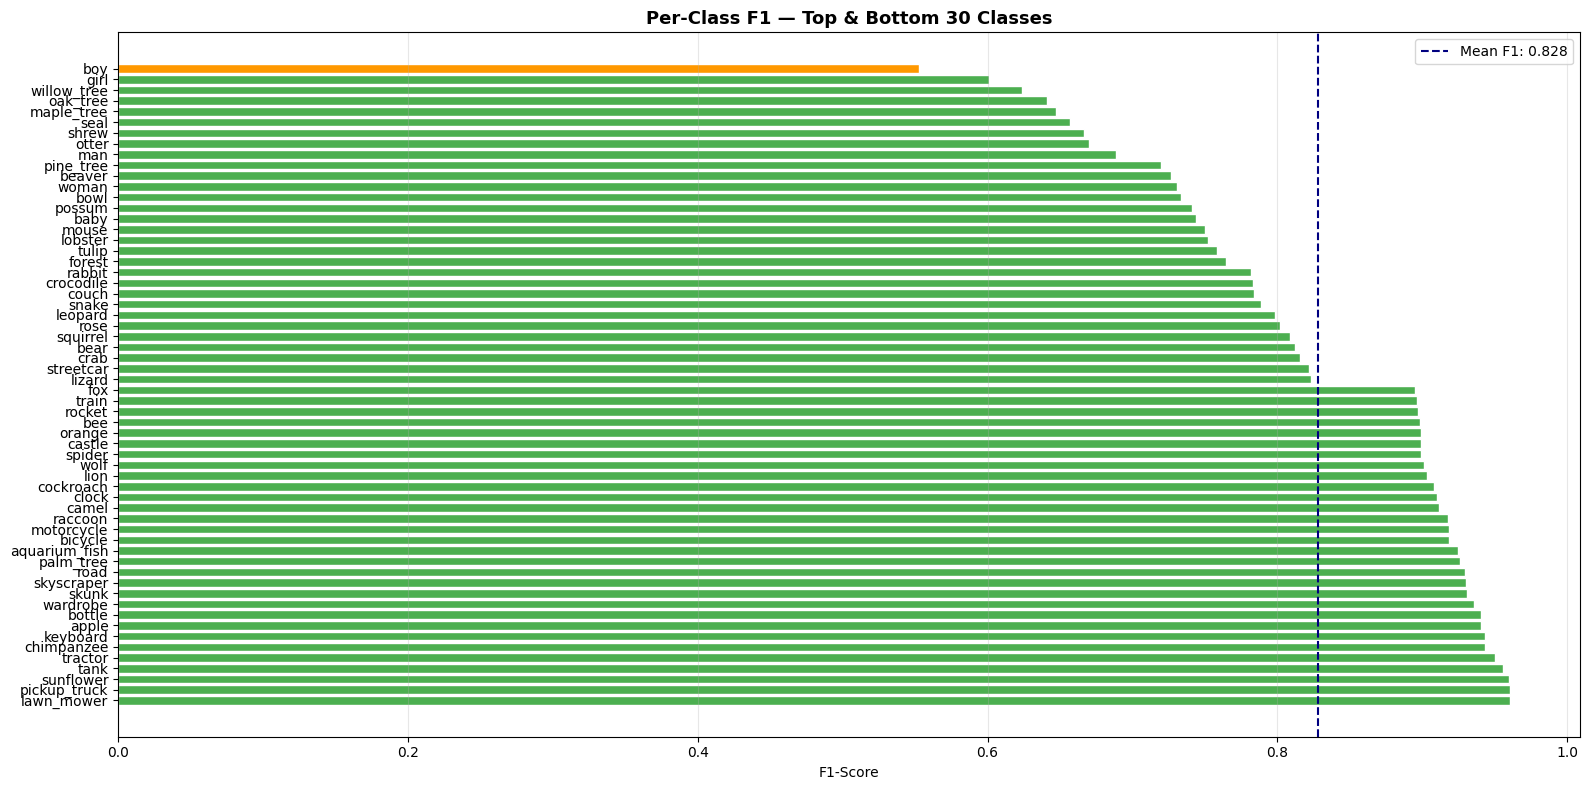

In [14]:
SHOW_TOP = 30  # Show top & bottom N classes for readability
f1_series = report_df["f1-score"].sort_values(ascending=False)
display_series = pd.concat([f1_series.head(SHOW_TOP), f1_series.tail(SHOW_TOP)])

colors = ["#4CAF50" if v >= 0.6 else "#FF9800" if v >= 0.4 else "#F44336"
          for v in display_series.values]

fig, ax = plt.subplots(figsize=(16, 8))
bars = ax.barh(display_series.index, display_series.values, color=colors, edgecolor="white")
ax.axvline(display_series.values.mean(), color="navy", linestyle="--", linewidth=1.5,
           label=f"Mean F1: {display_series.values.mean():.3f}")
ax.set_xlabel("F1-Score"); ax.set_title(f"Per-Class F1 — Top & Bottom {SHOW_TOP} Classes",
                                         fontsize=13, fontweight="bold")
ax.legend(); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("per_class_f1.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
total_params     = sum(p.numel() for p in model.parameters()) / 1e6
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6

summary = pd.DataFrame([
    ["Model",              CFG["model_name"]],
    ["Dataset",            f"{CFG['dataset']} ({CFG['num_classes']} classes)"],
    ["Total Params",       f"{total_params:.2f}M"],
    ["Trainable Params",   f"{trainable_params:.2f}M"],
    ["Pretrained",         str(CFG["pretrained"])],
    ["Epochs Trained",     str(epochs_ran)],
    ["Best Val Accuracy",  f"{best_val_acc*100:.2f}%"],
    ["Test Top-1 Accuracy",f"{test_acc*100:.2f}%"],
    ["Test Top-5 Accuracy",f"{top5_acc*100:.2f}%"],
    ["Test Loss",           f"{test_loss:.4f}"],
    ["Label Smoothing",    str(CFG["label_smoothing"])],
    ["Scheduler",          CFG["scheduler"]],
], columns=["Metric", "Value"])

print("\n" + "="*50)
print("  EXPERIMENT SUMMARY")
print("="*50)
print(summary.to_string(index=False))
print("="*50)


  EXPERIMENT SUMMARY
             Metric                  Value
              Model               resnet50
            Dataset CIFAR100 (100 classes)
       Total Params                 23.71M
   Trainable Params                 23.71M
         Pretrained                   True
     Epochs Trained                     20
  Best Val Accuracy                 82.12%
Test Top-1 Accuracy                 84.20%
Test Top-5 Accuracy                 97.03%
          Test Loss                 1.3015
    Label Smoothing                    0.1
          Scheduler                 cosine
